In [16]:
from py_eddy_tracker.dataset.grid import RegularGridDataset
from py_eddy_tracker.eddy_feature import Amplitude, Contours

from visualizer import get_axes, update_axes

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from datetime import datetime
from pathlib import Path

### Display the L4 mapped data on 2025-01-10

Unfiltered SWOT L4 absolute dynamic topography (ADT) on 2025-01-10, Gulf Stream region. The basin-scale gradient dominates the field; mesoscale eddies become visible only after high-pass filtering.

In [17]:
SWOT_DIR = Path('/Users/jerry/Desktop/school/research/eddy-tracking/data/gulf_stream_20241001_20250701/swot_l4')
sample_file = sorted(SWOT_DIR.glob('*.nc'))[9]
ds = xr.open_dataset(sample_file)
ds

<xarray.Dataset> Size: 1MB
Dimensions:           (longitude: 200, latitude: 120, time: 1, bounds: 2)
Coordinates:
  * longitude         (longitude) float32 800B -80.94 -80.81 ... -56.19 -56.06
  * latitude          (latitude) float32 480B 29.06 29.19 29.31 ... 43.81 43.94
  * time              (time) datetime64[ns] 8B 2025-01-10
    longitude_bounds  (longitude, bounds) float64 3kB ...
    latitude_bounds   (latitude, bounds) float64 2kB ...
Dimensions without coordinates: bounds
Data variables:
    sla               (time, latitude, longitude) float64 192kB ...
    ugosa             (time, latitude, longitude) float64 192kB ...
    vgosa             (time, latitude, longitude) float64 192kB ...
    adt               (time, latitude, longitude) float64 192kB ...
    ugos              (time, latitude, longitude) float64 192kB ...
    vgos              (time, latitude, longitude) float64 192kB ...
Attributes: (12/46)
    description:                      Miost analysis 
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         
    ...                              ...
    time_coverage_duration:          P1D
    time_coverage_resolution:        P1D
    title:                           DT merged all satellites Global Ocean Gr...
    time_coverage_start:             2025-01-10T12:00:00Z
    time_coverage_end:               2025-01-10T12:00:00Z
    doi:                             10.24400/527896/a01-2025.001

We assume pixel position of grid is centered for /Users/jerry/Desktop/school/research/eddy-tracking/data/gulf_stream_20241001_20250701/swot_l4/dt_global_allsat_phy_l4_20250110_20250826.nc


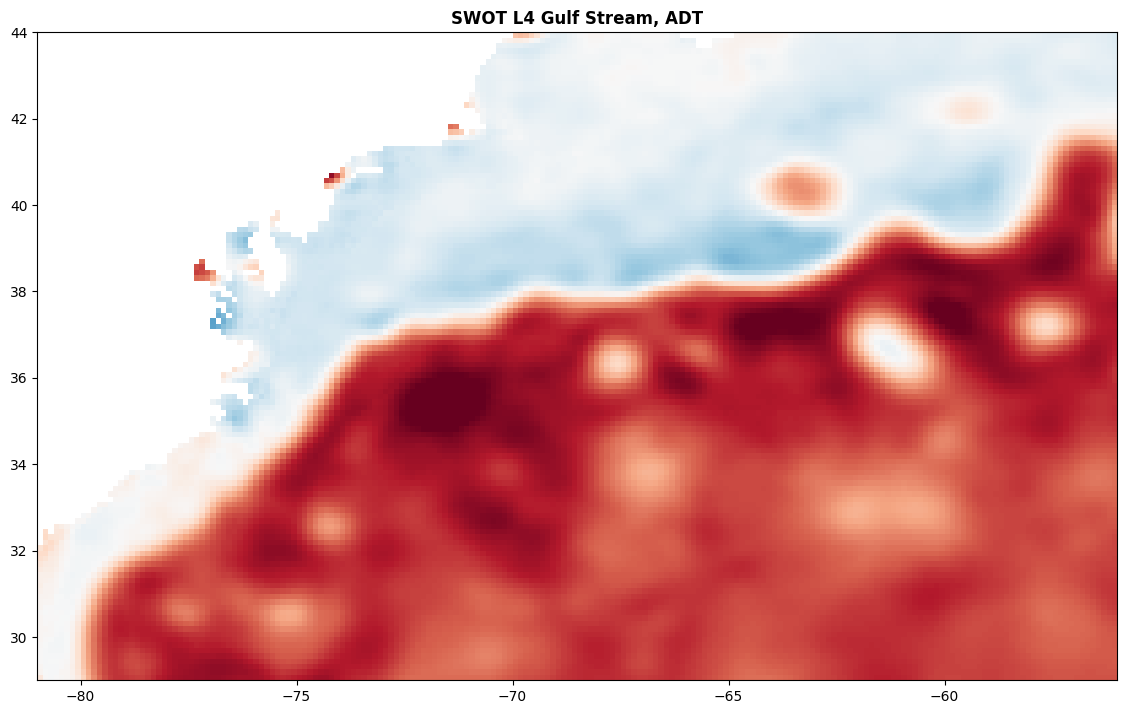

In [18]:
xlim = (-81, -56)
ylim = (29, 44)
g = RegularGridDataset(
    filename=str(sample_file),
    x_name='longitude',
    y_name='latitude',
    indexs={
        'time': 0
    }
)
ax = get_axes('SWOT L4 Gulf Stream, ADT', xlim, ylim)
m: ScalarMappable = g.display(ax, 'adt', vmin=-1, vmax=1, cmap='RdBu_r')

We assume pixel position of grid is centered for /Users/jerry/Desktop/school/research/eddy-tracking/data/gulf_stream_20241001_20250701/swot_l4/dt_global_allsat_phy_l4_20250110_20250826.nc


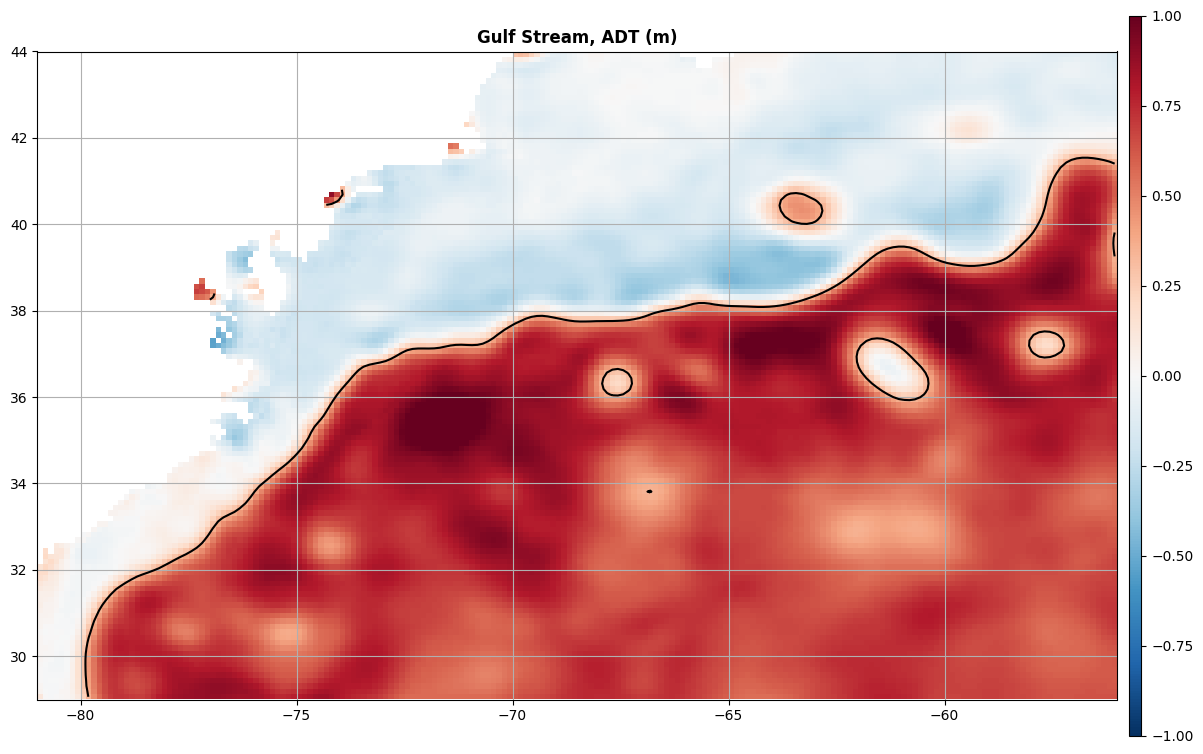

In [19]:
lon_min, lon_max = (-81, -56)
lat_min, lat_max = (29, 44)

lon = ds.coords['longitude'].to_numpy()
lat = ds.coords['latitude'].to_numpy()

i_lon_min = np.searchsorted(lon, lon_min, 'left')
i_lon_max = np.searchsorted(lon, lon_max, 'right')
i_lat_min = np.searchsorted(lat, lat_min, 'left')
i_lat_max = np.searchsorted(lat, lat_max, 'right')

g = RegularGridDataset(
    filename=str(sample_file),
    x_name='longitude',
    y_name='latitude',
    indexs={
        'time': 0,
        'longitude': slice(i_lon_min, i_lon_max),
        'latitude': slice(i_lat_min, i_lat_max)
    }
)
xlim = (lon_min, lon_max)
ylim = (lat_min, lat_max)

ax = get_axes('Gulf Stream, ADT (m)', xlim, ylim)
m: ScalarMappable = g.display(ax, 'adt', vmin=-1, vmax=1, cmap='RdBu_r')
gulf_stream = Contours(g.x_c, g.y_c, g.grid('adt'), levels=(0.35,), keep_unclose=True)
gulf_stream.display(ax, color='k')
update_axes(ax, m)

In [20]:
g.grid('adt')

masked_array(
  data=[[0.116, 0.0273, 0.0187, ..., --, --, --],
        [0.0057, -0.0058000000000000005, -0.0126, ..., --, --, --],
        [-0.0112, -0.0154, -0.0126, ..., --, --, --],
        ...,
        [0.6358, 0.6318, 0.6267, ..., -0.0995, -0.1029, -0.1052],
        [0.6355000000000001, 0.6304000000000001, 0.6238, ...,
         -0.10990000000000001, -0.115, -0.1178],
        [0.6343, 0.628, 0.6203000000000001, ..., -0.12240000000000001,
         -0.1307, -0.135]],
  mask=[[False, False, False, ...,  True,  True,  True],
        [False, False, False, ...,  True,  True,  True],
        [False, False, False, ...,  True,  True,  True],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],
  fill_value=-2147483647)

### Preprocessing

ADT after a 600 km Bessel high-pass filter to remove the basin-scale signal, isolating mesoscale eddy features. Gulf Stream mean dynamic topography overlaid in black as a geographic reference.

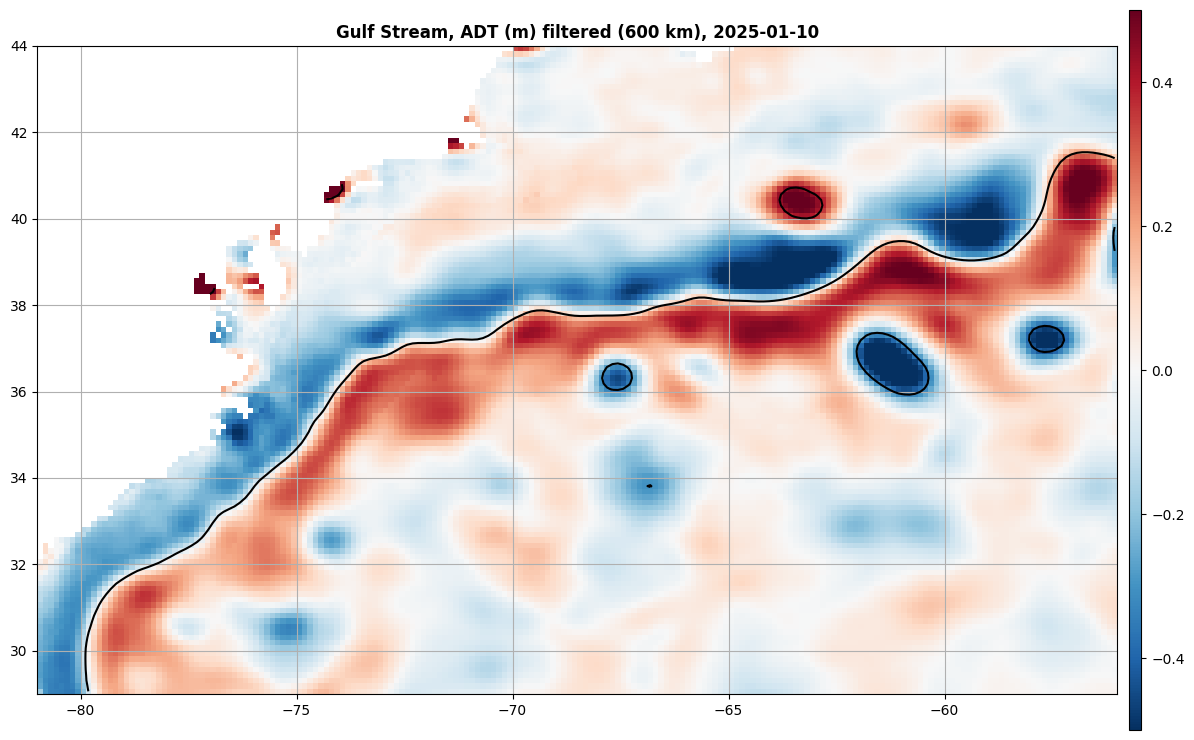

In [21]:
g.bessel_high_filter('adt', 600)
ax = get_axes('Gulf Stream, ADT (m) filtered (600 km), 2025-01-10', xlim, ylim)
m = g.display(ax, 'adt', vmin=-0.5, vmax=0.5, cmap='RdBu_r')
gulf_stream.display(ax, color='k')
update_axes(ax, m)

### Identification

Eddy identification results overlaid on filtered ADT. Closed contours detected by py-eddy-tracker (step = 0.004 m, shape error ≤ 50%) are shown for both cyclonic and anticyclonic eddies on 2025-01-10.

/Users/jerry/Desktop/school/research/py-eddy-tracker/src/py_eddy_tracker/dataset/grid.py:1915: RuntimeWarning: invalid value encountered in sqrt
  self._speed_ev = sqrt(u * u + v * v)
/opt/miniconda3/envs/eddy/lib/python3.10/site-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


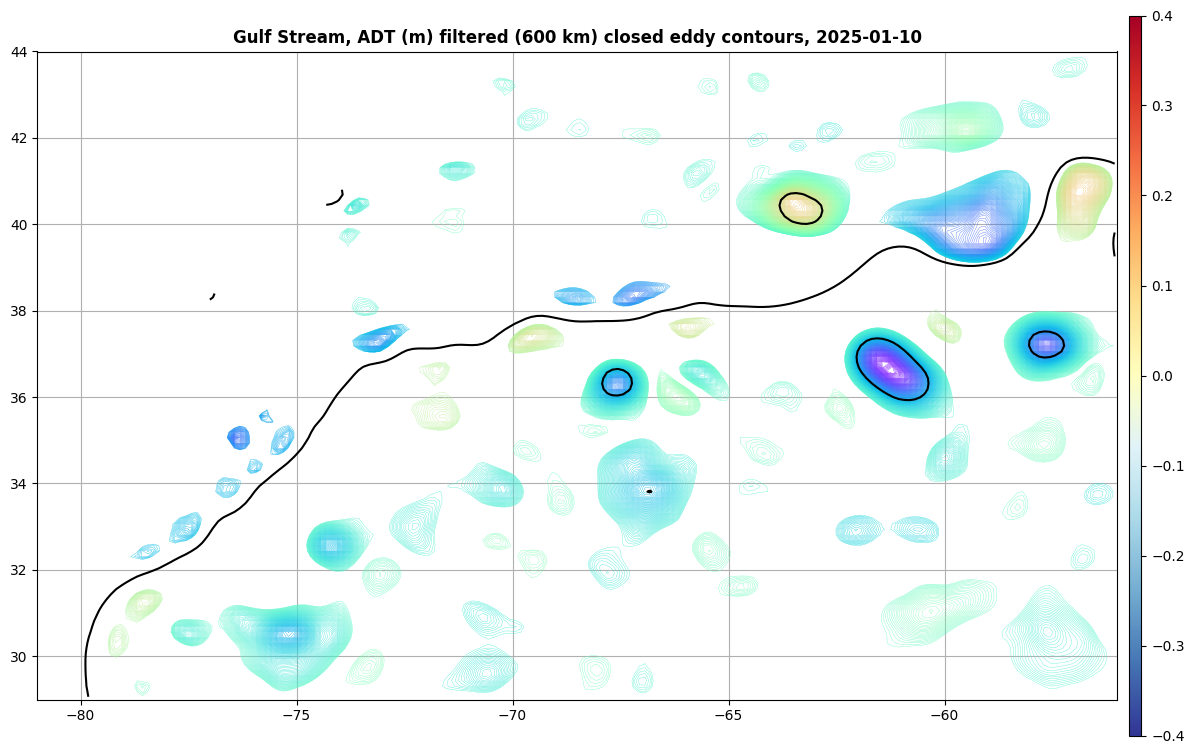

In [22]:
date = datetime(2025, 1, 10)
anticyclones, cyclones = g.eddy_identification(
    grid_height='adt',
    uname='ugos',
    vname='vgos',
    date=date,
    step=0.004,
    shape_error=50
)
ax = get_axes('Gulf Stream, ADT (m) filtered (600 km) closed eddy contours, 2025-01-10', xlim, ylim)
sm = ScalarMappable(norm=Normalize(vmin=-0.4, vmax=0.4), cmap='RdYlBu_r')
g.contours.display(ax, lw=0.25, only_used=True) #type:ignore
gulf_stream.display(ax, color='k')
update_axes(ax, sm)

### EddyNet Comparison

In [23]:
import torch

In [24]:
model: torch.nn.Module = torch.hub.load("edwinytgoh/eddynet", "eddynet", pretrained=True, num_classes=3) #type:ignore
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)

Using cache found in /Users/jerry/Downloads/torch-cache/hub/edwinytgoh_eddynet_master


In [25]:
adt = ds.data_vars['adt'].to_numpy().squeeze()
adt = adt[i_lat_min:i_lat_max, i_lon_min:i_lon_max]
adt_tensor = torch.from_numpy(adt).reshape(1, 1, *adt.shape).float().to(device)
adt_tensor[torch.isnan(adt_tensor)] = 0

logits = model(adt_tensor)
eddy_mask = torch.argmax(logits, dim=1).squeeze().cpu().numpy()

Comparison of filtered ADT field (top) and EddyNet deep-learning segmentation (bottom). EddyNet classifies each grid cell as background (gray), cyclonic (blue), or anticyclonic (red) using a pretrained CNN.

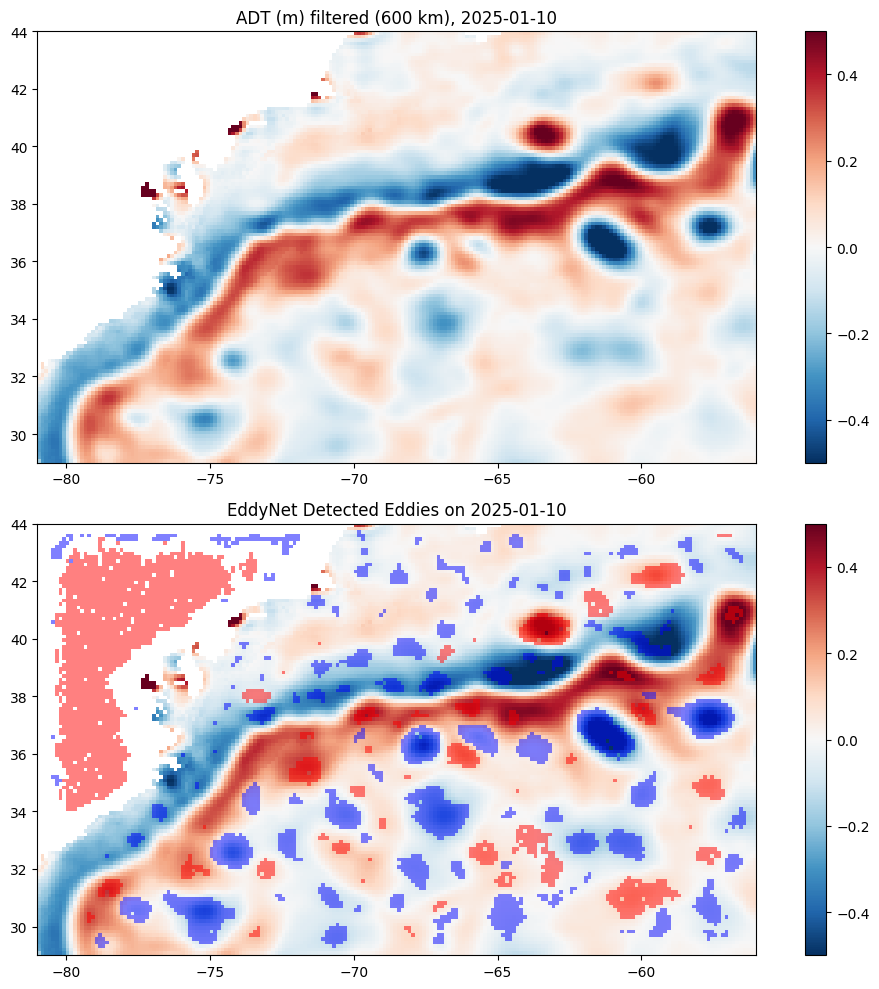

In [26]:
from matplotlib.colors import ListedColormap, BoundaryNorm

fig, ax = plt.subplots(2, 1, figsize=(10, 10))

# Top: filtered ADT
im = ax[0].imshow(g.grid('adt').T[::-1, ...], extent=[lon_min, lon_max, lat_min, lat_max], aspect='equal', vmin=-0.5, vmax=0.5, cmap='RdBu_r')
ax[0].set_title('ADT (m) filtered (600 km), 2025-01-10')
plt.colorbar(im, ax=ax[0])

# Bottom: filtered ADT with eddy mask overlay
im2 = ax[1].imshow(g.grid('adt').T[::-1, ...], extent=[lon_min, lon_max, lat_min, lat_max], aspect='equal', vmin=-0.5, vmax=0.5, cmap='RdBu_r')
cmap = ListedColormap(['none', 'red', 'blue'])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)
ax[1].imshow(eddy_mask[::-1, ...], extent=[lon_min, lon_max, lat_min, lat_max], aspect='equal', cmap=cmap, norm=norm, alpha=0.5)
ax[1].set_title('EddyNet Detected Eddies on 2025-01-10')
plt.colorbar(im2, ax=ax[1])
plt.tight_layout()

### PET Comparison

Filtered ADT (top) with py-eddy-tracker contour overlay (bottom). Dashed contours mark the effective radius (outer boundary); solid contours mark the speed radius (maximum rotational velocity). Red = anticyclonic, blue = cyclonic.

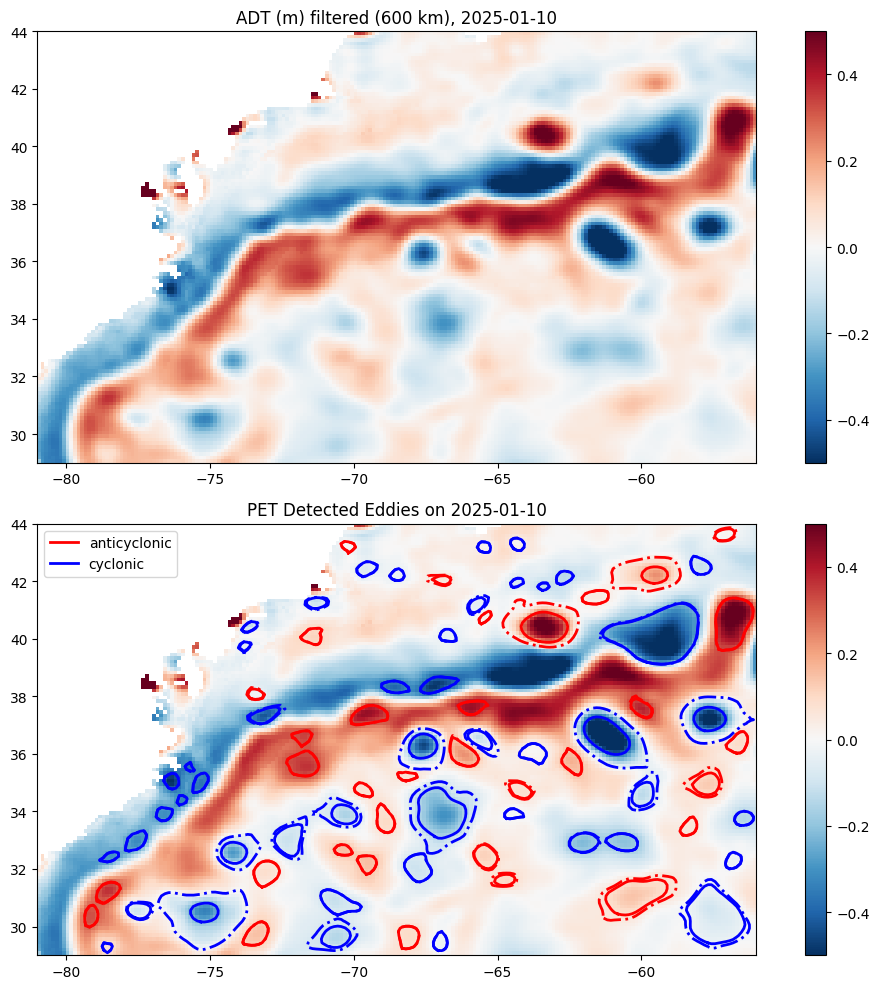

In [27]:
fig, ax = plt.subplots(2, 1, figsize=(10, 10))

# Top: filtered ADT
im = ax[0].imshow(g.grid('adt').T[::-1, ...], extent=[lon_min, lon_max, lat_min, lat_max], aspect='equal', vmin=-0.5, vmax=0.5, cmap='RdBu_r')
ax[0].set_title('ADT (m) filtered (600 km), 2025-01-10')
plt.colorbar(im, ax=ax[0])

# Bottom: filtered ADT with PET eddy contours overlay
im2 = ax[1].imshow(g.grid('adt').T[::-1, ...], extent=[lon_min, lon_max, lat_min, lat_max], aspect='equal', vmin=-0.5, vmax=0.5, cmap='RdBu_r')
anticyclones.display(ax[1], color='r', linewidth=2, label='anticyclonic', ref=-180)
cyclones.display(ax[1], color='b', linewidth=2, label='cyclonic', ref=-180)
ax[1].set_xlim(lon_min, lon_max)
ax[1].set_ylim(lat_min, lat_max)
ax[1].legend()
ax[1].set_title('PET Detected Eddies on 2025-01-10')
plt.colorbar(im2, ax=ax[1])
plt.tight_layout()

In [28]:
plt.close('all')

### Working with Identification File Outputs

Files like `Anticyclonic_20190223.nc` are daily snapshots of all eddies detected on a specific date.

**Dimensions:**
- `obs` - number of eddies detected that day (e.g., 3137 anticyclonic eddies on 2019-02-23)
- `NbSample` - number of points used to represent contours (fixed at 50)

**Core Variables (1D, shape: obs):**
- `longitude`, `latitude` - Eddy center coordinates
- `amplitude` - Height difference between center and edge (cm)
- `time` - Observation timestamp

**Effective Contour (outer boundary):**
- `effective_radius` - Radius of outer contour (km)
- `effective_area` - Area enclosed by outer contour
- `effective_contour_height` - SSH value at this contour
- `effective_contour_shape_error` - Circularity measure (0 = perfect circle)
- `effective_contour_longitude/latitude` - Contour coordinates (shape: obs × NbSample)

**Speed Contour (max rotational velocity):**
- `speed_radius` - Radius of max speed contour (km)
- `speed_area` - Area enclosed
- `speed_average` - Mean rotational speed at this contour
- `speed_contour_height` - SSH value at this contour
- `speed_contour_shape_error` - Circularity measure
- `speed_contour_longitude/latitude` - Contour coordinates (shape: obs × NbSample)

**Profile Data:**
- `uavg_profile` - Azimuthally-averaged velocity profile (shape: obs × NbSample)

In [29]:
from py_eddy_tracker import data
from py_eddy_tracker.observations.observation import EddiesObservations

In [30]:
a = EddiesObservations.load_file(data.get_demo_path("Anticyclonic_20190223.nc"))
c = EddiesObservations.load_file(data.get_demo_path("Cyclonic_20190223.nc"))